<font color = "blue">

#### Theory Driven Quant Trading Strategies
**Trend Following**
- Moving Average Crossover
- MACD (Moving Average Convergence Divergence)

**Mean Reversion**
- Bollinger Bands
- RSI (Relative Strength Index)
- Stochastic Oscillator

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#import yfinance as yf
import datetime

pd.options.mode.copy_on_write = True

import warnings
warnings.filterwarnings("always")

In [74]:
apple_df = pd.read_csv("AAPL.csv", index_col=0, parse_dates=True)
apple_df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,27.847500,27.860001,26.837500,27.332500,24.373960,212818400
2015-01-05,27.072500,27.162500,26.352501,26.562500,23.687307,257142000
2015-01-06,26.635000,26.857500,26.157499,26.565001,23.689531,263188400
2015-01-07,26.799999,27.049999,26.674999,26.937500,24.021717,160423600
2015-01-08,27.307501,28.037500,27.174999,27.972500,24.944685,237458000
...,...,...,...,...,...,...
2024-10-16,231.600006,232.119995,229.839996,231.779999,231.779999,34082200
2024-10-17,233.429993,233.850006,230.520004,232.149994,232.149994,32993800
2024-10-18,236.179993,236.179993,234.009995,235.000000,235.000000,46431500


In [75]:
start='2022-01-01'
end='2023-01-01'

df = apple_df.loc[start:end]
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100
...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400


<font color = "blue">

**1. Moving average crossover** strategy, uses two moving averages (a short-term and a long-term moving average) and generates buy/sell signals when they cross.

Common Crossover Pairs:
* Short-Term: **5-day and 20-day**
* Medium-Term: 20-day and 50-day
* Long-Term: 50-day and 200-day (Golden Cross and Death Cross)

In [76]:
# Load stock data
df = apple_df.loc[start: end]

# Calculate short and long moving averages
df['Short_MA'] = df['Close'].rolling(window=5).mean()
df['Long_MA'] = df['Close'].rolling(window=20).mean()
df


,Open,High,Low,Close,Adj Close,Volume,Short_MA,Long_MA
Date,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,NaN,NaN
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,NaN,NaN
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,NaN,NaN
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,176.159998,NaN
...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,132.841998,140.6610
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,132.373999,139.9515
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,131.121999,139.1950


In [77]:
# Generate signals
df['Signal'] = 0
df.loc[df['Short_MA'] > df['Long_MA'], 'Signal'] = 1   # Buy signal
df.loc[df['Short_MA'] < df['Long_MA'], 'Signal'] = -1  # Sell signal

df['Position'] = df['Signal'].diff()
df

,Open,High,Low,Close,Adj Close,Volume,Short_MA,Long_MA,Signal,Position
Date,,,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,NaN,0,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,NaN,NaN,0,0.0
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,NaN,NaN,0,0.0
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,NaN,NaN,0,0.0
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,176.159998,NaN,0,0.0
...,...,...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,132.841998,140.6610,-1,0.0
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,132.373999,139.9515,-1,0.0
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,131.121999,139.1950,-1,0.0


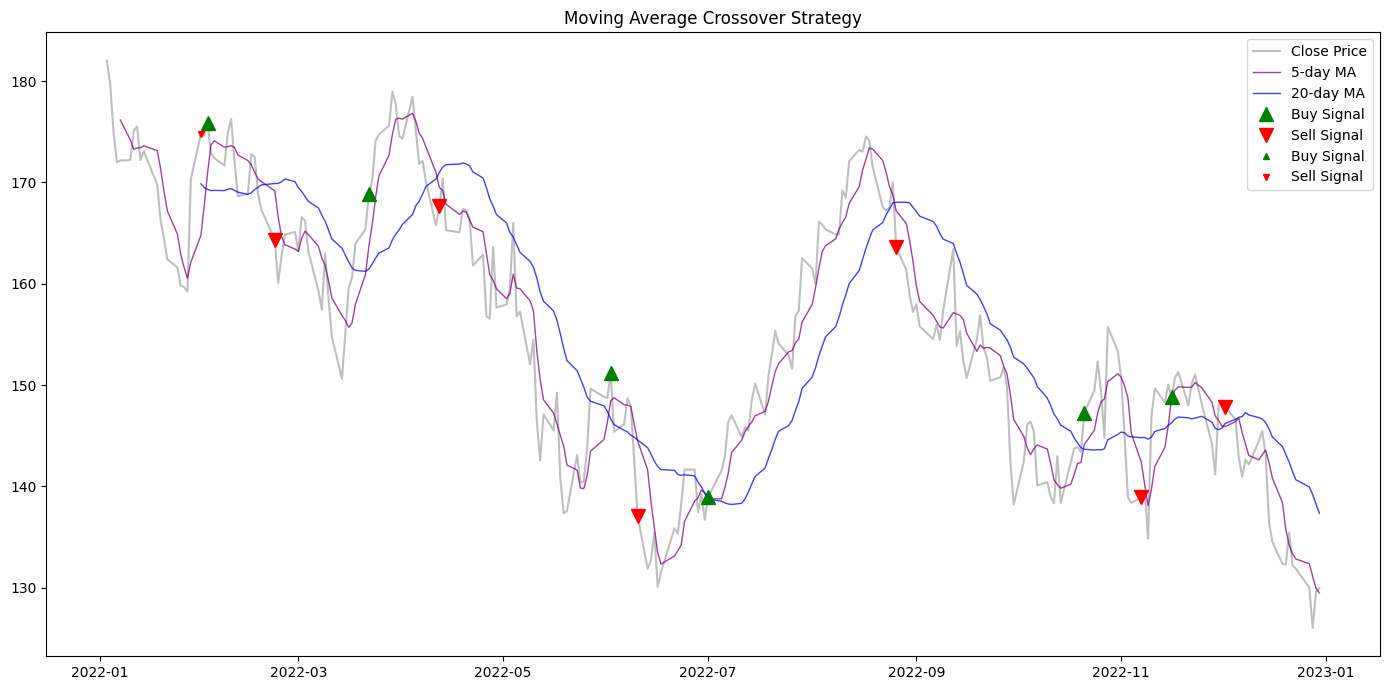

In [78]:
# Plot strategy
plt.figure(figsize=(14,7))
plt.plot(df.index, df['Close'], label='Close Price', color="grey", alpha=0.5)
plt.plot(df.index, df['Short_MA'], label='5-day MA', color="purple", alpha=0.75, lw=1)
plt.plot(df.index, df['Long_MA'], label='20-day MA', color="blue", alpha=0.75, lw=1)

plt.plot(df[df['Position'] == 2].index, df['Close'][df['Position'] == 2], '^', markersize=10, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -2].index, df['Close'][df['Position'] == -2], 'v', markersize=10, color='r', label='Sell Signal')

plt.plot(df[df['Position'] == 1].index, df['Close'][df['Position'] == 1], '^', markersize=5, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, df['Close'][df['Position'] == -1], 'v', markersize=5, color='r', label='Sell Signal')

plt.title('Moving Average Crossover Strategy')
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
# Backtest
def back_test(df, title):
    df['Returns'] = df['Close'].pct_change()
    df['Strategy_Returns'] = df['Returns'] * df['Signal'].shift(1)
    df['Cumulative_Strategy_Returns'] = (1 + df['Strategy_Returns']).cumprod()
    df['Cumulative_Market_Returns'] = (1 + df['Returns']).cumprod()

    # Mean strategy return and standard deviation of returns
    mean_strategy_return = df['Strategy_Returns'].mean()
    std_strategy_return = df['Strategy_Returns'].std()

    # Sharpe Ratio: (Mean Return - Risk-Free Rate) / Std of Returns
    # Assume the risk-free rate is 0. Let's calculate it on an annualized basis.
    annual_factor = 252  # Trading days in a year
    sharpe_ratio = (mean_strategy_return * annual_factor) / (std_strategy_return * np.sqrt(annual_factor))
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')

    # Calculate the drawdown: (Current Value - Cumulative Max) / Cumulative Max
    df['Cumulative_Max'] = df['Cumulative_Strategy_Returns'].cummax()
    df['Drawdown'] = (df['Cumulative_Strategy_Returns'] - df['Cumulative_Max']) / df['Cumulative_Max']

    # Max Drawdown
    max_drawdown = df['Drawdown'].min()
    print(f'Max Drawdown: {max_drawdown * 100:.2f}%')

    # Max Drawdown Day
    max_drawdown_day = df['Drawdown'].idxmin().date()
    print(f'Max Drawdown Day: {max_drawdown_day}')

    # CAGR(Compound Annual Growth Rate): (Ending Value / Starting Value) ^ (1 / Number of Years) - 1
    new_df = df.copy().dropna()
    n_years = (new_df.index[-1] - new_df.index[0]).days / 365.25
    market_cagr = (new_df['Cumulative_Market_Returns'].iloc[-1] / new_df['Cumulative_Market_Returns'].iloc[0]) ** (1 / n_years) - 1
    print(f'Market CAGR: {market_cagr * 100:.2f}%')
    strategy_cagr = (new_df['Cumulative_Strategy_Returns'].iloc[-1] / new_df['Cumulative_Strategy_Returns'].iloc[0]) ** (1 / n_years) - 1
    print(f'Strategy CAGR: {strategy_cagr * 100:.2f}%')

    plt.figure(figsize=(10,5))
    plt.plot(df['Cumulative_Strategy_Returns'], color="green", label='Strategy Returns')
    plt.plot(df['Cumulative_Market_Returns'], color="grey", label='Market Returns')
    plt.title(title)
    plt.legend()
    plt.show()

Sharpe Ratio: 0.38
Max Drawdown: -22.88%
Max Drawdown Day: 2022-11-29
Market CAGR: -27.77%
Strategy CAGR: 7.99%


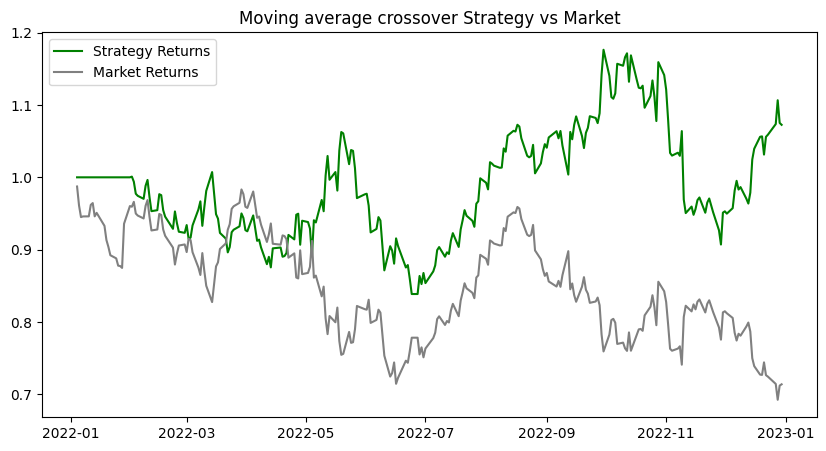

In [80]:
# Backtest the strategy
back_test(df, "Moving average crossover Strategy vs Market")

<font color = "blue">

**2. MACD (Moving Average Convergence Divergence)** is used to identify changes in momentum, trends, and potential buy/sell signals. The MACD strategy is based on the difference between two exponential moving averages (EMAs) of different periods. It consists of three main components:

i. **MACD Line**: The difference between the 12-period and 26-period EMAs.
   
$
   \text{MACD Line} = \text{EMA}(12) - \text{EMA}(26)
   $


ii. **Signal Line**: A 9-period EMA of the MACD Line.
   
$
   \text{Signal Line} = \text{EMA}(\text{MACD Line}, 9)
   $


iii. **MACD Histogram**: The difference between the MACD Line and the Signal Line.
   
$
   \text{MACD Histogram} = \text{MACD Line} - \text{Signal Line}
   $

- **Buy Signal**: When the MACD Line crosses above the Signal Line (bullish crossover).
- **Sell Signal**: When the MACD Line crosses below the Signal Line (bearish crossover).

In [81]:
# Download stock data
df = apple_df.loc[start: end]

# Calculate the 12-day and 26-day EMAs
df['12_EMA'] = df['Close'].ewm(span=12, adjust=False).mean()
df['26_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
df


,Open,High,Low,Close,Adj Close,Volume,12_EMA,26_EMA
Date,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,182.009995,182.009995
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,181.654610,181.838884
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,180.618516,181.326374
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,179.292591,180.635531
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,178.196807,180.008455
...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,136.767190,140.437884
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,135.730699,139.666930
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,134.239822,138.657528


**When `adjust=False`**, the calculation is done recursively using formula: $ \text{EMA}_t = \alpha \cdot \text{Close}_t + (1 - \alpha) \cdot \text{EMA}_{t-1} $

Where $ \alpha $ is the smoothing factor, calculated as: $ \alpha = \frac{2}{\text{span} + 1} $


The recursive calculation, instead of applying weights across all historical data when `adjust=True`, makes it a faster.

In [82]:
# Calculate the MACD Line
df['MACD_Line'] = df['12_EMA'] - df['26_EMA']

# Calculate the Signal Line (9-day EMA of the MACD Line)
df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()

# Calculate the MACD Histogram (difference between MACD Line and Signal Line)
df['MACD_Histogram'] = df['MACD_Line'] - df['Signal_Line']

# Generate Buy and Sell signals
df['Signal'] = 0
df.loc[df['MACD_Line'] > df['Signal_Line'], 'Signal'] = 1   # Buy signal
df.loc[df['MACD_Line'] < df['Signal_Line'], 'Signal'] = -1  # Sell signal
df['Position'] = df['Signal'].diff()
df

,Open,High,Low,Close,Adj Close,Volume,12_EMA,26_EMA,MACD_Line,Signal_Line,MACD_Histogram,Signal,Position
Date,,,,,,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,182.009995,182.009995,0.000000,0.000000,0.000000,0,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,181.654610,181.838884,-0.184273,-0.036855,-0.147419,-1,-1.0
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,180.618516,181.326374,-0.707857,-0.171055,-0.536802,-1,0.0
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,179.292591,180.635531,-1.342941,-0.405432,-0.937508,-1,0.0
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,178.196807,180.008455,-1.811647,-0.686675,-1.124972,-1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,136.767190,140.437884,-3.670694,-2.570162,-1.100532,-1,0.0
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,135.730699,139.666930,-3.936231,-2.843376,-1.092855,-1,0.0
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,134.239822,138.657528,-4.417705,-3.158241,-1.259464,-1,0.0


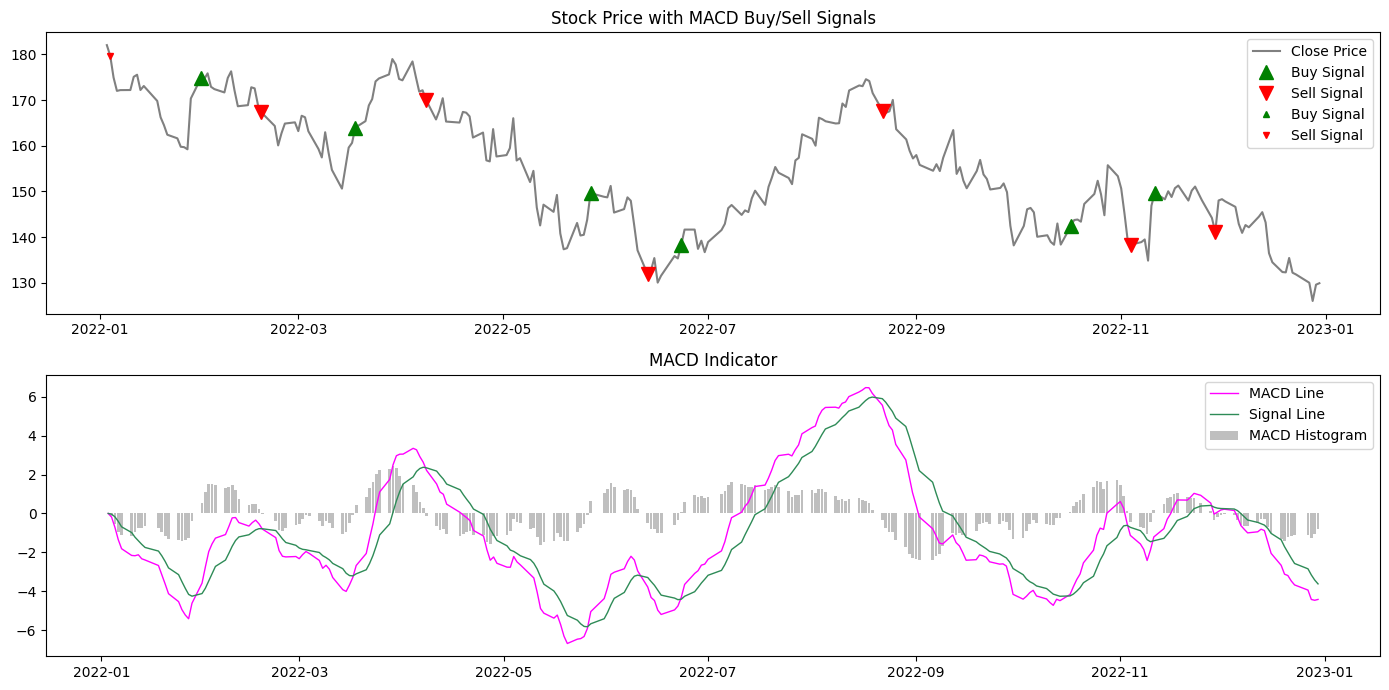

In [83]:
# Plotting the strategy
plt.figure(figsize=(14, 7))

# Plot close price and signals
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Close Price', color='grey')

plt.plot(df[df['Position'] == 2].index, df['Close'][df['Position'] == 2], '^', markersize=10, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -2].index, df['Close'][df['Position'] == -2], 'v', markersize=10, color='r', label='Sell Signal')

plt.plot(df[df['Position'] == 1].index, df['Close'][df['Position'] == 1], '^', markersize=5, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, df['Close'][df['Position'] == -1], 'v', markersize=5, color='r', label='Sell Signal')

plt.title('Stock Price with MACD Buy/Sell Signals')
plt.legend()

# Plot the MACD Line and Signal Line
plt.subplot(2, 1, 2)
plt.plot(df.index, df['MACD_Line'], label='MACD Line', color='magenta', lw=1)
plt.plot(df.index, df['Signal_Line'], label='Signal Line', color='seagreen', lw=1)
plt.bar(df.index, df['MACD_Histogram'], label='MACD Histogram', color='gray', alpha=0.5)

plt.title('MACD Indicator')
plt.legend()

plt.tight_layout()
plt.show()

Sharpe Ratio: 0.69
Max Drawdown: -27.14%
Max Drawdown Day: 2022-12-01
Market CAGR: -28.04%
Strategy CAGR: 20.05%


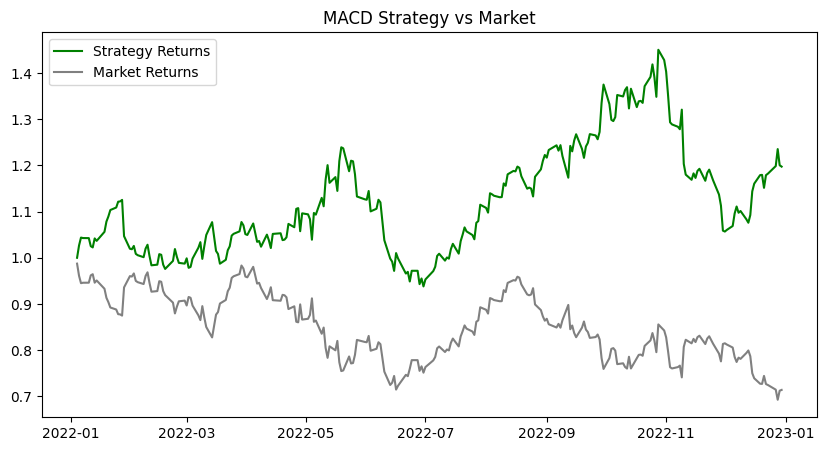

In [84]:
# Backtest the strategy
back_test(df, "MACD Strategy vs Market")

<font color = "blue">

**3. Bollinger Bands** are used to identify overbought and oversold conditions in a market. Bollinger Bands consist of three components:

1. **Middle Band**: A simple moving average (SMA) of the asset’s price over a given period (usually 20 days).
2. **Upper Band**: Two standard deviations above the middle band.
3. **Lower Band**: Two standard deviations below the middle band.

- When prices move close to the **upper band**, the asset might be considered **overbought**.
- When prices move close to the **lower band**, the asset might be considered **oversold**.


In [85]:
# Load stock data
df = apple_df.loc[start: end]

# Calculate Bollinger Bands
window = 20
df['SMA'] = df['Close'].rolling(window=window).mean()
df['STD'] = df['Close'].rolling(window=window).std()
df['Upper_Band'] = df['SMA'] + (2 * df['STD'])
df['Lower_Band'] = df['SMA'] - (2 * df['STD'])
df

,Open,High,Low,Close,Adj Close,Volume,SMA,STD,Upper_Band,Lower_Band
Date,,,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,NaN,NaN,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,NaN,NaN,NaN,NaN
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,NaN,NaN,NaN,NaN
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,NaN,NaN,NaN,NaN
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,140.6610,5.792854,152.246708,129.075292
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,139.9515,6.189422,152.330344,127.572656
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,139.1950,6.914779,153.024558,125.365442


In [87]:
# Generate signals
df['Signal'] = np.nan
df.loc[df['Close'] < df['Lower_Band'], 'Signal'] = 1   # Buy signal
df.loc[df['Close'] > df['Upper_Band'], 'Signal'] = -1  # Sell signal

distance = df['Close'] - df['SMA']
prev_distance = distance.shift(1)
df.loc[distance * prev_distance < 0, 'Signal'] = 0  # Reset signal
df['Signal'] = df['Signal'].ffill()

df['Position'] = df['Signal'].diff()
df

,Open,High,Low,Close,Adj Close,Volume,SMA,STD,Upper_Band,Lower_Band,Signal,Position
Date,,,,,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,140.6610,5.792854,152.246708,129.075292,1.0,0.0
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,139.9515,6.189422,152.330344,127.572656,1.0,0.0
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,139.1950,6.914779,153.024558,125.365442,1.0,0.0


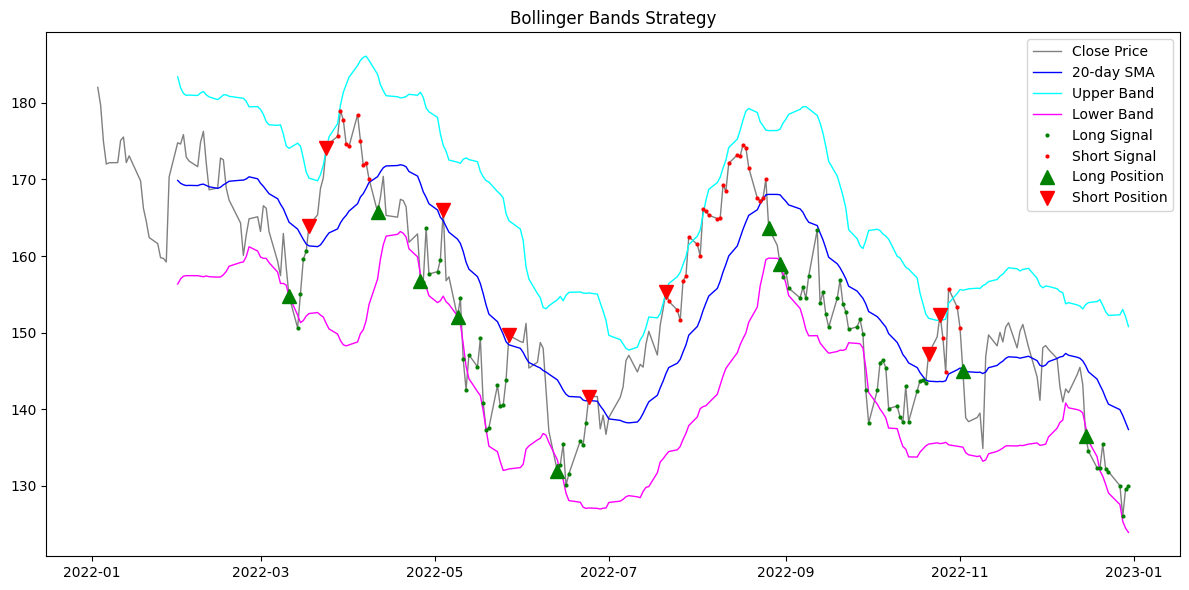

In [88]:
# Plot strategy
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close Price', color='grey', lw=1)
plt.plot(df.index, df['SMA'], label='20-day SMA', color='blue', lw=1)
plt.plot(df.index, df['Upper_Band'], label='Upper Band', color='cyan', lw=1)
plt.plot(df.index, df['Lower_Band'], label='Lower Band', color='magenta', lw=1)

# Plot buy and sell signals
plt.plot(df[df['Signal'] == 1].index, df['Close'][df['Signal'] == 1], 'o', markersize=2, color='g', label='Long Signal')
plt.plot(df[df['Signal'] == -1].index, df['Close'][df['Signal'] == -1], 'o', markersize=2, color='r', label='Short Signal')

plt.plot(df[df['Position'] > 0].index, df['Close'][df['Position'] > 0], '^', markersize=10, color='g', label='Long Position')
plt.plot(df[df['Position'] < 0].index, df['Close'][df['Position'] < 0], 'v', markersize=10, color='r', label='Short Position')

plt.title('Bollinger Bands Strategy')
plt.legend()
plt.tight_layout()
plt.show()

Sharpe Ratio: 0.43
Max Drawdown: -20.03%
Max Drawdown Day: 2022-09-30
Market CAGR: -25.93%
Strategy CAGR: 8.59%


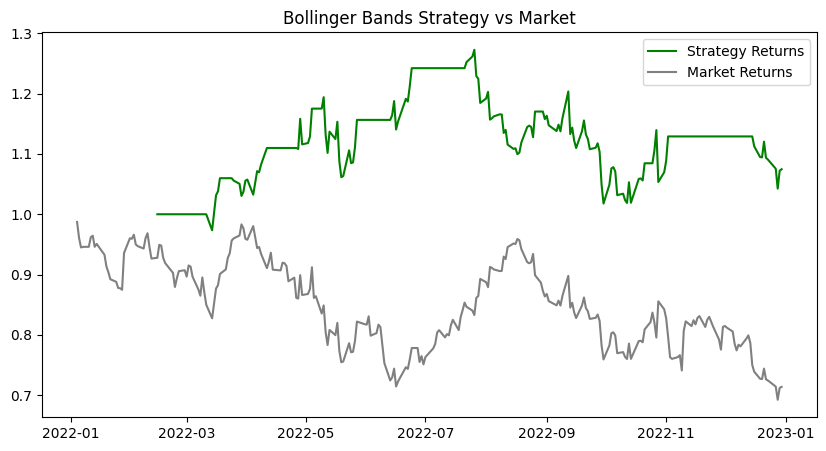

In [89]:
# Backtest the strategy
back_test(df, "Bollinger Bands Strategy vs Market")

<font color = "blue">

**4. RSI (Relative Strength Index)**  is a momentum oscillator that measures the speed and magnitude of an asset's recent price changes to determine whether it is overbought or oversold.

**Gain** = The difference between the current price and the previous price, if positive (0 otherwise).

**Loss** = The difference between the previous price and the current price, if positive (0 otherwise).

$
\text{RS} = \frac{\text{Average Gain over 14 periods}}{\text{Average Loss over 14 periods}}
$


$
RSI = 100 - \left( \frac{100}{1 + RS} \right)
$

- **RSI values** range from 0 to 100.
- An RSI above 70 is often considered **overbought** (sell signal).
- An RSI below 30 is often considered **oversold** (buy signal).

In [90]:
# Load stock data
df = apple_df.loc[start: end]

# Calculate daily price changes
df['Change'] = df['Close'].diff()

# Calculate gains and losses
df['Gain'] = np.where(df['Change'] > 0, df['Change'], 0)
df['Loss'] = np.where(df['Change'] < 0, -df['Change'], 0)

# Calculate rolling averages for gains and losses
window_length = 7
df['Avg_Gain'] = df['Gain'].rolling(window=window_length, min_periods=1).mean()
df['Avg_Loss'] = df['Loss'].rolling(window=window_length, min_periods=1).mean()

# Calculate the RS and RSI
df['RS'] = df['Avg_Gain'] / df['Avg_Loss']
df['RSI'] = 100 - (100 / (1 + df['RS']))
df

,Open,High,Low,Close,Adj Close,Volume,Change,Gain,Loss,Avg_Gain,Avg_Loss,RS,RSI
Date,,,,,,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,-2.309998,0.000000,2.309998,0.000000,1.154999,0.000000,0.000000
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,-4.779999,0.000000,4.779999,0.000000,2.363332,0.000000,0.000000
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,-2.919998,0.000000,2.919998,0.000000,2.502499,0.000000,0.000000
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,0.169998,0.169998,0.000000,0.034000,2.001999,0.016983,1.669924
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,-0.369995,0.000000,0.369995,0.449999,2.071429,0.217241,17.846997
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,-1.830002,0.000000,1.830002,0.449999,1.374285,0.327442,24.667162
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,-3.989998,0.000000,3.989998,0.449999,1.659998,0.271084,21.327000


In [91]:
# Define RSI thresholds and generate signals
rsi_buy = 30
rsi_sell = 70

df['Signal'] = np.nan
df.loc[df['RSI'] < rsi_buy, 'Signal'] = 1   # Buy signal
df.loc[df['RSI'] > rsi_sell, 'Signal'] = -1  # Sell signal
df['Signal'] = df['Signal'].ffill()

df['Position'] = df['Signal'].diff()
df

,Open,High,Low,Close,Adj Close,Volume,Change,Gain,Loss,Avg_Gain,Avg_Loss,RS,RSI,Signal,Position
Date,,,,,,,,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,-2.309998,0.000000,2.309998,0.000000,1.154999,0.000000,0.000000,1.0,NaN
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,-4.779999,0.000000,4.779999,0.000000,2.363332,0.000000,0.000000,1.0,0.0
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,-2.919998,0.000000,2.919998,0.000000,2.502499,0.000000,0.000000,1.0,0.0
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,0.169998,0.169998,0.000000,0.034000,2.001999,0.016983,1.669924,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,-0.369995,0.000000,0.369995,0.449999,2.071429,0.217241,17.846997,1.0,0.0
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,-1.830002,0.000000,1.830002,0.449999,1.374285,0.327442,24.667162,1.0,0.0
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,-3.989998,0.000000,3.989998,0.449999,1.659998,0.271084,21.327000,1.0,0.0


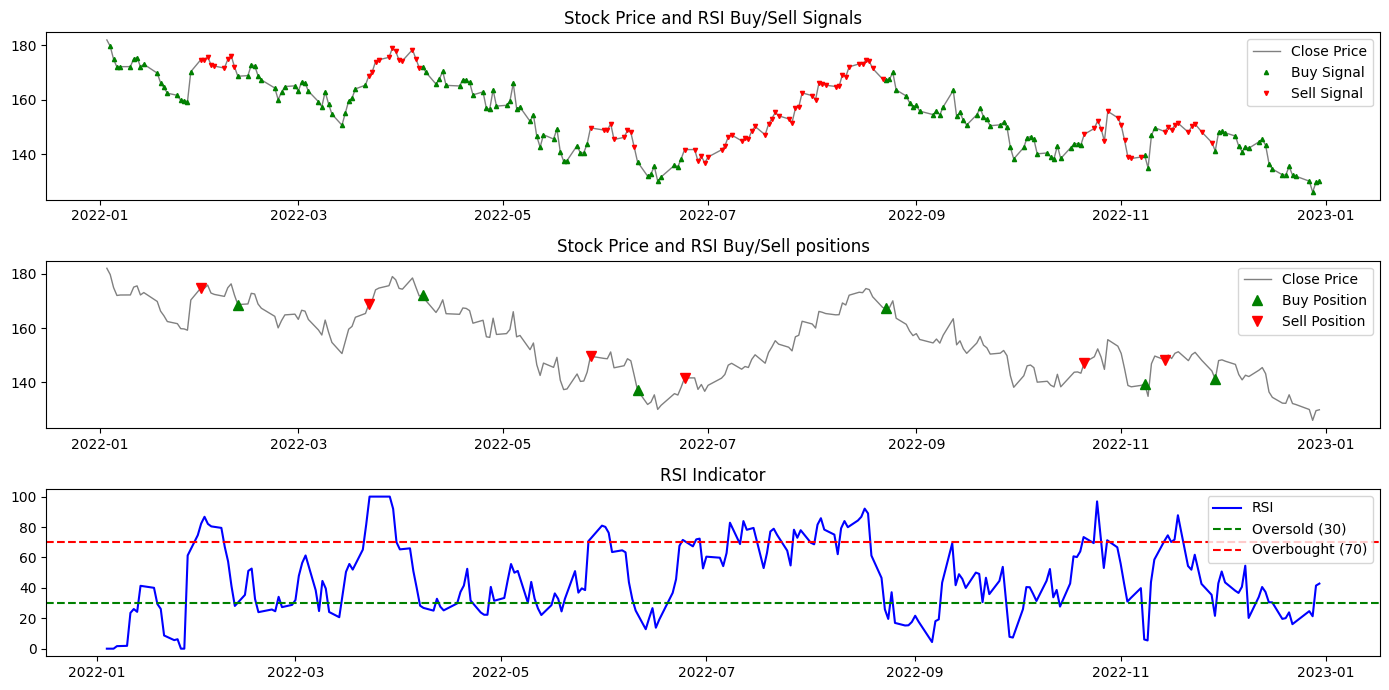

In [92]:
# Plotting the strategy
plt.figure(figsize=(14, 7))

# Plot Close price and signals
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Close'], label='Close Price', color='grey', lw=1)
plt.plot(df[df['Signal'] == 1].index, df['Close'][df['Signal'] == 1], '^', markersize=3, color='g', label='Buy Signal')
plt.plot(df[df['Signal'] == -1].index, df['Close'][df['Signal'] == -1], 'v', markersize=3, color='r', label='Sell Signal')
plt.title('Stock Price and RSI Buy/Sell Signals')
plt.legend()

# Plot Close price and positions
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Close'], label='Close Price', color='grey', lw=1)
plt.plot(df[df['Position'] > 0].index, df['Close'][df['Position'] > 0], '^', markersize=7, color='g', label='Buy Position')
plt.plot(df[df['Position'] < 0].index, df['Close'][df['Position'] < 0], 'v', markersize=7, color='r', label='Sell Position')
plt.title('Stock Price and RSI Buy/Sell positions')
plt.legend()

# Plot RSI
plt.subplot(3, 1, 3)
plt.plot(df.index, df['RSI'], label='RSI', color='blue')
plt.axhline(y=rsi_buy, color='green', linestyle='--', label='Oversold (30)')
plt.axhline(y=rsi_sell, color='red', linestyle='--', label='Overbought (70)')
plt.title('RSI Indicator')
plt.legend()

plt.tight_layout()
plt.show()

Sharpe Ratio: -0.61
Max Drawdown: -35.49%
Max Drawdown Day: 2022-09-30
Market CAGR: -26.10%
Strategy CAGR: -22.45%


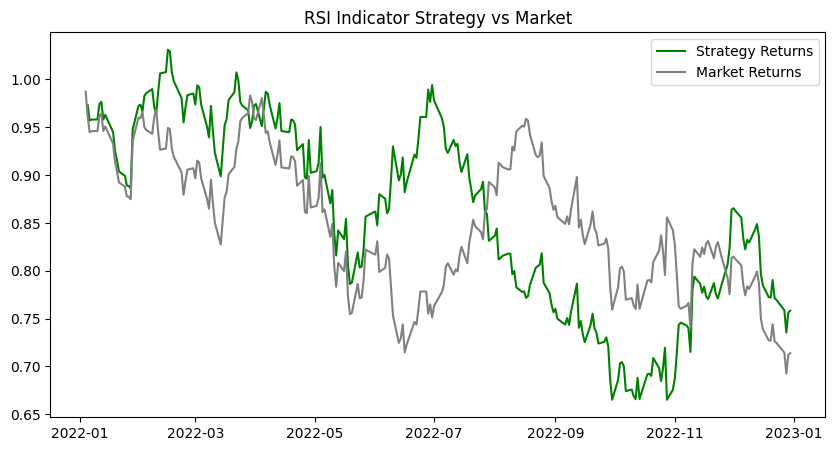

In [93]:
# Backtest the strategy
back_test(df, "RSI Indicator Strategy vs Market")

<font color = "blue">

**5. Stochastic Oscillator** is a momentum indicator that compares closing price of a security to a range of its prices over a certain period of time.
 
The Stochastic Oscillator oscillates between 0 and 100 and consists of two lines: %K Line and %D Line.

**%K**: Represents the current closing price in relation to the high-low range over 14 periods.

**%D**: A 3-period moving average of %K.

When the Stochastic Oscillator is **above 80**, it suggests that the asset may be **overbough**t. When the Stochastic Oscillator is **below 20**, it suggests that the asset may be **oversold**.

**Buy Signal**: If the %K line crosses above the %D line when both are in the oversold region (below 20).

**Sell Signal**: If the %K line crosses below the %D line when both are in the overbought region (above 80).

In [95]:
# Download stock data
df = apple_df.loc[start: end]

# Calculate the 14-day high and low
low_14 = df['Low'].rolling(window=14).min()
high_14 = df['High'].rolling(window=14).max()

# Calculate %K (Stochastic Oscillator)
df['%K'] = (df['Close'] - low_14) / (high_14 - low_14) * 100

# Calculate %D (3-day moving average of %K)
df['%D'] = df['%K'].rolling(window=3).mean()
df

,Open,High,Low,Close,Adj Close,Volume,%K,%D
Date,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,NaN,NaN
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,NaN,NaN
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,NaN,NaN
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,NaN,NaN
...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,10.919828,16.161728
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,6.164694,9.403822
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,0.705387,5.929970


In [97]:
# Generate Buy and Sell signals
df['Signal'] = np.nan
df.loc[(df['%K'] < 20) & (df['%K'] > df['%D']), 'Signal'] = 1   # Buy signal
df.loc[(df['%K'] > 80) & (df['%K'] < df['%D']), 'Signal'] = -1  # Sell signal
df['Signal'] = df['Signal'].ffill()

df['Position'] = df['Signal'].diff()
df

,Open,High,Low,Close,Adj Close,Volume,%K,%D,Signal,Position
Date,,,,,,,,,,
2022-01-03,177.830002,182.880005,177.710007,182.009995,179.273590,104487900,NaN,NaN,NaN,NaN
2022-01-04,182.630005,182.940002,179.119995,179.699997,176.998352,99310400,NaN,NaN,NaN,NaN
2022-01-05,179.610001,180.169998,174.639999,174.919998,172.290207,94537600,NaN,NaN,NaN,NaN
2022-01-06,172.699997,175.300003,171.639999,172.000000,169.414108,96904000,NaN,NaN,NaN,NaN
2022-01-07,172.889999,174.139999,171.029999,172.169998,169.581543,86709100,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,130.631348,63814900,10.919828,16.161728,1.0,0.0
2022-12-27,131.380005,131.410004,128.720001,130.029999,128.818420,69007800,6.164694,9.403822,1.0,0.0
2022-12-28,129.669998,131.029999,125.870003,126.040001,124.865578,85438400,0.705387,5.929970,1.0,0.0


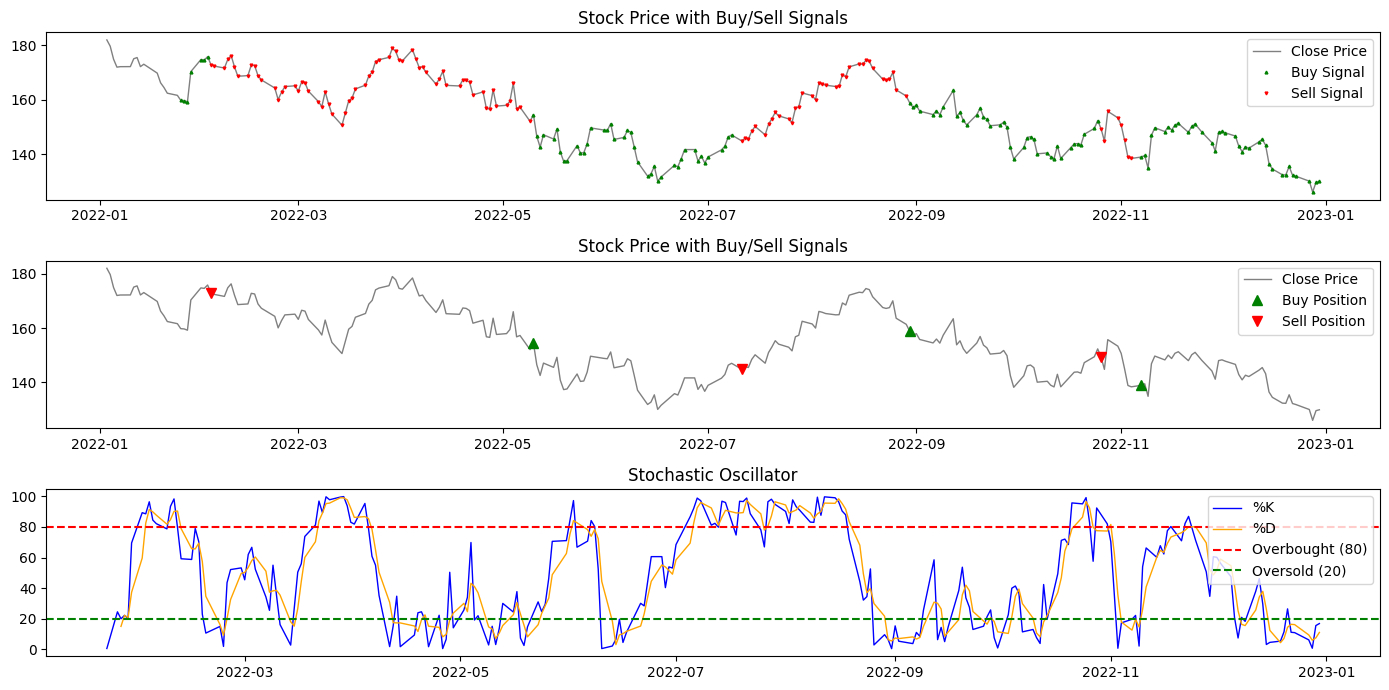

In [98]:
# Plotting the strategy
plt.figure(figsize=(14, 7))

# Plot close price and signals
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Close'], label='Close Price', color='grey', lw=1)
plt.plot(df[df['Signal'] == 1].index, df['Close'][df['Signal'] == 1], '^', markersize=2, color='g', label='Buy Signal')
plt.plot(df[df['Signal'] == -1].index, df['Close'][df['Signal'] == -1], 'v', markersize=2, color='r', label='Sell Signal')
plt.title('Stock Price with Buy/Sell Signals')
plt.legend()

# Plot close price and positions
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Close'], label='Close Price', color='grey', lw=1)
plt.plot(df[df['Position'] > 0].index, df['Close'][df['Position'] > 0], '^', markersize=7, color='g', label='Buy Position')
plt.plot(df[df['Position'] < 0].index, df['Close'][df['Position'] < 0], 'v', markersize=7, color='r', label='Sell Position')
plt.title('Stock Price with Buy/Sell Signals')
plt.legend()

# Plot the Stochastic Oscillator
plt.subplot(3, 1, 3)
plt.plot(df.index, df['%K'], label='%K', color='blue', lw=1)
plt.plot(df.index, df['%D'], label='%D', color='orange', lw=1)
plt.axhline(80, color='red', linestyle='--', label='Overbought (80)')
plt.axhline(20, color='green', linestyle='--', label='Oversold (20)')
plt.title('Stochastic Oscillator')
plt.legend()

plt.tight_layout()
plt.show()

Sharpe Ratio: -0.03
Max Drawdown: -29.67%
Max Drawdown Day: 2022-09-30
Market CAGR: -19.98%
Strategy CAGR: -7.34%


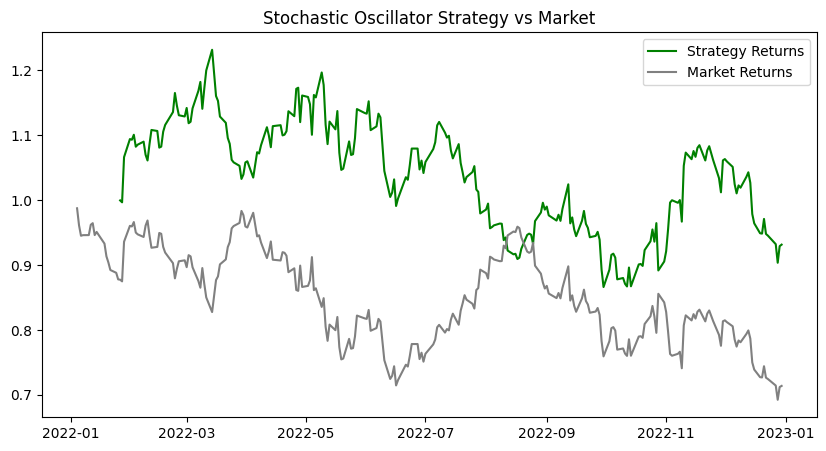

In [99]:
# Backtest the strategy
back_test(df, "Stochastic Oscillator Strategy vs Market")